# When sales hide demand

The tea shop from notebook 04 orders every Monday from a one-week forecast. There, the forecaster learned from **demand**: every unit customers wanted, including units the shop could not supply. A shop's till records **sales**. In a week that runs out of stock, sales stop at the stock on the shelf, and the rest of the demand is never seen. **What happens to the orders when the forecaster can only learn from sales?**

This notebook follows the same three steps as notebook 04:

1. **One week up close.** A stockout turns 31 units of demand into 24 units of sales.
2. **Through time.** Two forecasters run side by side for sixteen weeks: one learns from demand, as in notebook 04, and one learns only from sales.
3. **The simulator.** A small policy refits the forecast at every decision from the run's own history, so `SimulationEngine` gives the same result.

We use Smooth for the forecasts again, but any forecasting library would do.

## 1. The shop's demand

The demand is notebook 04's, with eight more weeks. These are artificial, uncensored weekly observations for a durable product. The first 20 weeks were observed before the run; the shop had stock in every one of them, so its sales equal its demand. During the 16 run weeks the tea becomes more popular, and demand moves into the high twenties.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from smooth import ES

sku = "tea_250g"
frequency = "W-MON"
probability = 0.90

# Show floats with two decimals in every table below.
pd.options.display.float_format = "{:.2f}".format

In [2]:
weeks_1_to_10 = [18, 20, 17, 22, 19, 21, 16, 23, 20, 18]
weeks_11_to_20 = [21, 24, 17, 19, 22, 20, 18, 23, 21, 19]
history_values = weeks_1_to_10 + weeks_11_to_20
notebook_04_weeks = [20, 23, 26, 18, 31, 22, 25, 19]
busier_weeks = [27, 24, 29, 26, 32, 25, 28, 30]
future_values = notebook_04_weeks + busier_weeks

dates = pd.date_range(
    "2025-01-06",
    periods=len(history_values) + len(future_values),
    freq=frequency,
)
series = pd.DataFrame({"date": dates, "y": history_values + future_values})
history = series.iloc[: len(history_values)].copy()
held_out = series.iloc[len(history_values) :].copy().reset_index(drop=True)

print("Weeks observed before the run:", len(history), "| run weeks:", len(held_out))

# The eight weeks added after notebook 04's run.
held_out.tail(len(busier_weeks))

Weeks observed before the run: 20 | run weeks: 16


,date,y
8,2025-07-21,27
9,2025-07-28,24
10,2025-08-04,29
11,2025-08-11,26
12,2025-08-18,32
13,2025-08-25,25
14,2025-09-01,28
15,2025-09-08,30


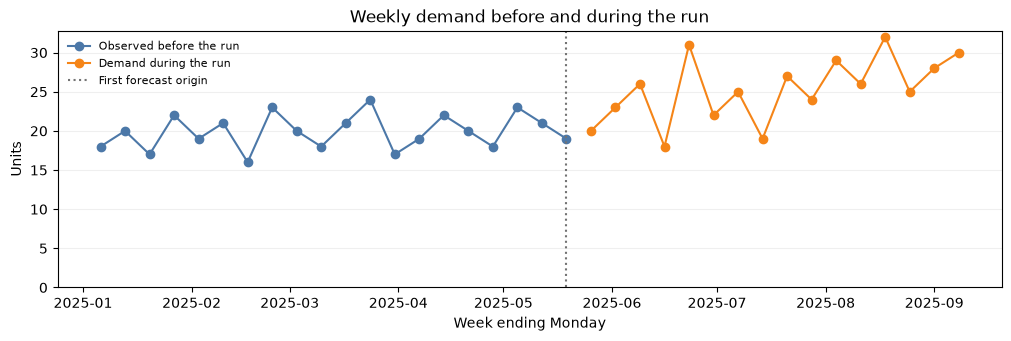

In [3]:
HISTORY_COLOR = "#4C78A8"
DEMAND_COLOR = "#F58518"
FROM_DEMAND_COLOR = "#54A24B"
FROM_SALES_COLOR = "#B279A2"

fig, ax = plt.subplots(figsize=(10, 3.3), layout="constrained")
ax.plot(
    history.date,
    history.y,
    marker="o",
    color=HISTORY_COLOR,
    label="Observed before the run",
)
ax.plot(
    held_out.date,
    held_out.y,
    marker="o",
    color=DEMAND_COLOR,
    label="Demand during the run",
)
ax.axvline(
    history.date.iloc[-1],
    color="0.45",
    linestyle=":",
    label="First forecast origin",
)
ax.set(
    title="Weekly demand before and during the run",
    ylabel="Units",
    xlabel="Week ending Monday",
)
ax.set_ylim(bottom=0)
ax.legend(frameon=False, fontsize=8)
ax.grid(axis="y", alpha=0.2)
plt.show()

## 2. A stockout hides demand

Take the week of 23 June from notebook 04. The shop starts the week with 24 units on the shelf, and customers want 31. `InventoryStateDataFrame` from `stockcast.core` holds the stock, and `fulfill_demand` serves what it can.

In [4]:
from stockcast.core import InventoryStateDataFrame

stockout_week = held_out.date.iloc[4]
empty_state = InventoryStateDataFrame([sku], max_lead_time=0, allow_backorders=False)
shelf_stock = pd.DataFrame({"unique_id": [sku], "on_hand": [24.0]})
week_start = empty_state.initialize_from_observed(
    shelf_stock,
    on_hand_column="on_hand",
    opening_date=stockout_week - pd.offsets.Week(weekday=0),
)

state = week_start.advance_period(freq=frequency, is_review_period=False)
week_demand = pd.DataFrame({"unique_id": [sku], "date": [stockout_week], "y": [31.0]})
state = state.fulfill_demand(week_demand)

# Demand splits into units sold and lost sales.
week_row = state.get_dataframe().iloc[0]
wanted = week_row["latest_incoming_demand"]
sold = week_row["latest_fulfilled"]
lost = week_row["latest_shortage"]
assert wanted == sold + lost

stockout_columns = [
    "unique_id",
    "date",
    "latest_incoming_demand",
    "latest_fulfilled",
    "latest_shortage",
    "on_hand",
]
state.get_dataframe()[stockout_columns]

,unique_id,date,latest_incoming_demand,latest_fulfilled,latest_shortage,on_hand
0,tea_250g,2025-06-23,31.00,24.00,7.00,0.00


The state records all three numbers: the demand that arrived (`latest_incoming_demand`), the units sold (`latest_fulfilled`) and the lost sales (`latest_shortage`). A real shop usually records only the 24 units sold; the 7 customers who found an empty shelf leave no trace. A forecaster that learns from sales therefore sees 24 for this week, although 31 units were wanted.

## 3. Forecast from what the shop records

`plan_week` is notebook 04's handoff with one change: it takes the observations to learn from as an argument, instead of reading the demand series. The same function then serves both forecasters. It fits `ES(model="ANN")` to the observations, takes the one-step upper prediction bound at the 90% level, rounds it up to whole units, and fits `OrderUpToPolicy` from `stockcast.policies` with that stock-position target.

In [5]:
from stockcast.policies import OrderUpToPolicy


def plan_week(observations, origin, week_date):
    """Forecast from `observations`, known at `origin`, and fit the policy for one week."""
    assert origin < week_date  # the week being planned is never in the fit data

    model = ES(model="ANN")
    model.fit(pd.Series(observations, dtype=float))
    forecast = model.predict(
        h=1,
        interval="prediction",
        level=probability,
        side="upper",
        cumulative=False,
    )
    forecast_mean = float(forecast.mean.iloc[0])
    upper_bound = float(forecast.upper.iloc[0, 0])
    assert np.isfinite([forecast_mean, upper_bound]).all() and upper_bound >= 0

    target_table = pd.DataFrame(
        {
            "unique_id": [sku],
            "target": [int(np.ceil(upper_bound))],
            "target_end": [week_date],
        }
    )
    policy = OrderUpToPolicy(
        lead_time=0,
        review_period=1,
        freq=frequency,
        service_level=probability,
        allow_backorders=False,
        date_column="target_end",
    )
    policy.fit(target_table, target_column="target", forecast_origin=origin)

    forecast_row = {
        "forecast_mean": forecast_mean,
        "upper_90": upper_bound,
        "stock_target": int(target_table["target"].iloc[0]),
    }
    return policy, forecast_row

## 4. Sixteen weeks with each forecaster

The loop is notebook 04's loop, run once for each forecaster from the same opening stock of 4 units. After each week, the forecaster adds one observation to what it learns from: the week's demand, or the week's sales read from the stock state (`latest_fulfilled`). The four calls inside are the same as before: `advance_period`, `predict`, `update_inventory_with_orders` from `stockcast.utils`, and `fulfill_demand`.

In [6]:
from stockcast.utils import update_inventory_with_orders

opening_stock = pd.DataFrame({"unique_id": [sku], "on_hand": [4.0]})
opening = empty_state.initialize_from_observed(
    opening_stock,
    on_hand_column="on_hand",
    opening_date=history.date.iloc[-1],
)

In [7]:
def run_weeks(learn_from):
    """Run the weekly loop; after each week, learn from its demand or its sales."""
    observations = list(history["y"])
    state = opening
    origin = history.date.iloc[-1]
    rows = []
    for week_number, week in enumerate(held_out.itertuples(index=False)):
        # Forecast from what this forecaster has learned so far, then fit the policy.
        policy, forecast_row = plan_week(observations, origin, week.date)

        # Open the week, order, then serve the week's demand.
        state = state.advance_period(
            freq=frequency,
            is_review_period=policy.schedule.should_decide(week_number),
        )
        current_period = int(state.get_dataframe()["period"].iloc[0])
        decision = policy.predict(state, current_period=current_period)
        state = update_inventory_with_orders(state, decision, policy=policy)
        week_demand = pd.DataFrame(
            {"unique_id": [sku], "date": [week.date], "y": [float(week.y)]}
        )
        state = state.fulfill_demand(week_demand)

        after = state.get_dataframe().iloc[0]
        learned = week.y if learn_from == "demand" else after["latest_fulfilled"]
        observations.append(float(learned))
        rows.append(
            {
                "date": week.date,
                **forecast_row,
                "demand": float(week.y),
                "learned": float(learned),
                "ordered": after["latest_order"],
                "sold": after["latest_fulfilled"],
                "end_on_hand": after["on_hand"],
                "lost_sales": after["latest_shortage"],
            }
        )
        origin = week.date  # the next forecast may use this week
    return pd.DataFrame(rows)

In [8]:
from_demand = run_weeks("demand")
from_sales = run_weeks("sales")

# Sales equal demand in weeks with stock left, and fall short in stockout weeks.
sales_seen = from_sales["learned"]
stockout = from_sales["lost_sales"] > 0
assert (sales_seen[~stockout] == from_sales["demand"][~stockout]).all()
assert (sales_seen[stockout] < from_sales["demand"][stockout]).all()

### Compare the two forecasters

Each row is one Monday. `sales_seen` is what the sales forecaster learned that week; the two targets are the stock positions each forecaster asked for.

In [9]:
side_by_side = pd.DataFrame(
    {
        "date": from_demand["date"],
        "demand": from_demand["demand"],
        "sales_seen": from_sales["learned"],
        "target_from_demand": from_demand["stock_target"],
        "target_from_sales": from_sales["stock_target"],
        "lost_from_demand": from_demand["lost_sales"],
        "lost_from_sales": from_sales["lost_sales"],
    }
)
side_by_side

,date,demand,sales_seen,target_from_demand,target_from_sales,lost_from_demand,lost_from_sales
0,2025-05-26,20.00,20.00,23,23,0.00,0.00
1,2025-06-02,23.00,23.00,23,23,0.00,0.00
2,2025-06-09,26.00,23.00,23,23,3.00,3.00
3,2025-06-16,18.00,18.00,24,24,0.00,0.00
4,2025-06-23,31.00,24.00,24,24,7.00,7.00
5,2025-06-30,22.00,22.00,25,24,0.00,0.00
6,2025-07-07,25.00,24.00,27,24,0.00,1.00
7,2025-07-14,19.00,19.00,28,24,0.00,0.00
8,2025-07-21,27.00,24.00,27,24,0.00,3.00
9,2025-07-28,24.00,24.00,28,25,0.00,0.00


The two targets are identical for the first five weeks, but what the forecasters learn parts earlier. The first stockout, on 9 June, hides 3 units: 26 were wanted and 23 were sold, so the sales forecaster learns 23. That does not move its target yet; the targets part on 30 June. From then on it learns a lower number in every stockout week. Its target stays at 24 from 16 June to 21 July, while the demand forecaster's target climbs to 27 and 28. Low targets cause more stockouts, and every stockout hides a little more demand. In the last week the demand forecaster asks for 32 units and the sales forecaster for 29. The first eight rows of the demand forecaster repeat notebook 04's weeks.

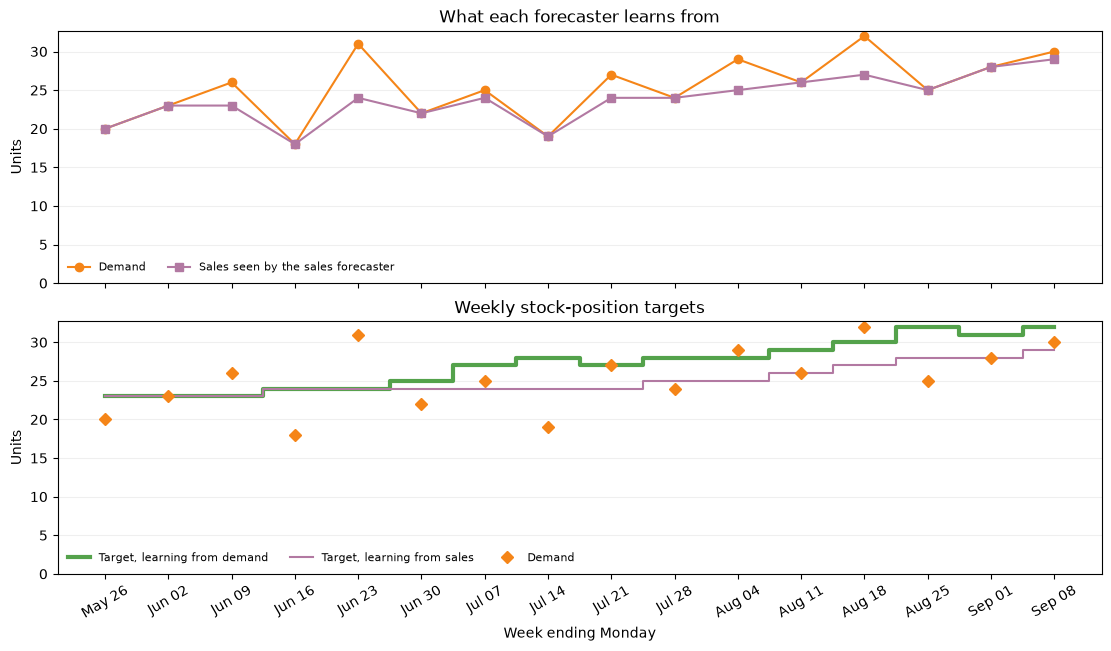

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True, layout="constrained")
axes[0].plot(
    from_sales.date,
    from_sales.demand,
    marker="o",
    color=DEMAND_COLOR,
    label="Demand",
)
axes[0].plot(
    from_sales.date,
    from_sales.learned,
    marker="s",
    color=FROM_SALES_COLOR,
    label="Sales seen by the sales forecaster",
)
axes[0].set(title="What each forecaster learns from", ylabel="Units")
axes[0].legend(frameon=False, ncol=2, fontsize=8)

axes[1].step(
    from_demand.date,
    from_demand.stock_target,
    where="mid",
    color=FROM_DEMAND_COLOR,
    linewidth=3,  # visible where the two targets coincide
    label="Target, learning from demand",
)
axes[1].step(
    from_sales.date,
    from_sales.stock_target,
    where="mid",
    color=FROM_SALES_COLOR,
    label="Target, learning from sales",
)
axes[1].plot(
    from_sales.date,
    from_sales.demand,
    marker="D",
    linestyle="none",
    color=DEMAND_COLOR,
    label="Demand",
)
axes[1].set(
    title="Weekly stock-position targets",
    ylabel="Units",
    xlabel="Week ending Monday",
)
axes[1].legend(frameon=False, ncol=3, fontsize=8)

for ax in axes:
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.2)
# One tick per week (each is a Monday).
axes[1].set_xticks(from_sales.date)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[1].tick_params(axis="x", labelrotation=30)
plt.show()

- The upper panel shows demand and the sales the second forecaster learns from. The lines split in every stockout week.
- The lower panel shows the two targets against demand. They are one line until 23 June; from 7 July on, the sales target is 3 or 4 units lower every week.

## 5. Let the simulator refit the forecast

In notebook 04 we prepared every policy snapshot before the run. That works when the forecast learns from demand: demand comes from the table, whatever the shop orders. The sales forecaster is different. The sales of a week depend on the stock, which depends on earlier orders, which depend on earlier forecasts. Its forecasts can only be made during the run, from what the run has recorded so far.

`SimulationEngine` calls the policy's `predict` before each week's demand, with the current stock state. `state.get_history()` on that state lists every completed week and never the current one. So a small policy can refit the forecast at each decision: it reads the history, calls `plan_week`, and lets the fitted `OrderUpToPolicy` compute the order. `BasePolicy` from `stockcast.core` is the base class for such a policy; notebook 05 shows custom policies in depth.

In [11]:
from stockcast.core import BasePolicy


class RefitEveryWeek(BasePolicy):
    """Refit the weekly forecast from the run's own history before each order."""

    columns = {"demand": "latest_incoming_demand", "sales": "latest_fulfilled"}

    def __init__(self, learn_from):
        super().__init__(
            lead_time=0,
            review_period=1,
            service_level=probability,
            allow_backorders=False,
        )
        self.learn_from = learn_from

    def fit(self, observations):
        # The weeks observed before the run; the forecast is fitted in predict.
        self.observations = list(observations)
        self.fitted_ = True
        return self

    def predict(self, state, *, current_period, **kwargs):
        week_date = state.get_dataframe()["date"].iloc[0]
        origin = week_date - pd.offsets.Week(weekday=0)
        past = state.get_history()  # every completed week, never the current one
        learned = list(past[self.columns[self.learn_from]]) if len(past) else []
        policy, _ = plan_week(self.observations + learned, origin, week_date)
        return policy.predict(state, current_period=current_period)

`run_comparison` runs both policies on the same demand from the same opening stock. Each branch keeps its own history, so the sales forecaster learns from its own stockouts. The policy class records no forecast frequency, so the run is given `freq` directly.

In [12]:
from stockcast.core import SimulationEngine

learns_from_demand = RefitEveryWeek(learn_from="demand")
learns_from_demand.fit(history["y"])
learns_from_sales = RefitEveryWeek(learn_from="sales")
learns_from_sales.fit(history["y"])

run_demand = pd.DataFrame(
    {
        "unique_id": sku,
        "period": range(len(held_out)),
        "date": held_out["date"],
        "y": held_out["y"].astype(float),
    }
)
comparison = SimulationEngine().run_comparison(
    policies={
        "learns from demand": learns_from_demand,
        "learns from sales": learns_from_sales,
    },
    demand_source=run_demand,
    inventory=opening,
    freq=frequency,
)

# The engine gives the same orders and lost sales as the loops in section 4.
loops = {"learns from demand": from_demand, "learns from sales": from_sales}
for label, loop in loops.items():
    events = comparison[label].to_event_frame()
    period_events = events.loc[events["event_type"] == "period"]
    assert np.allclose(period_events["order_quantity"], loop["ordered"])
    assert np.allclose(period_events["lost_sales_units"], loop["lost_sales"])

The comparison summary reads the event tables. We add the total lost sales of each run.

In [13]:
outcomes = comparison.summary()[["fill_rate", "stockout_periods", "total_order_units"]]
outcomes["lost_sales_units"] = [
    comparison[label].to_event_frame()["lost_sales_units"].sum()
    for label in outcomes.index
]
outcomes

,fill_rate,stockout_periods,total_order_units,lost_sales_units
policy,,,,
learns from demand,0.97,4,390.00,13.00
learns from sales,0.94,7,377.00,24.00


Over these sixteen artificial weeks, the forecaster that learned from sales lost 24 units of sales against 13, ran out of stock in 7 weeks against 4, and reached a fill rate of 0.94 against 0.97. The cause is the stockouts themselves: each one hides part of a week's demand from the forecaster. Correcting sales for stockouts, for example by treating a stockout week as "at least 24", is a forecasting choice, and `predict` is the place to make it: the history gives the forecaster demand, sales, lost sales and stock for every completed week.